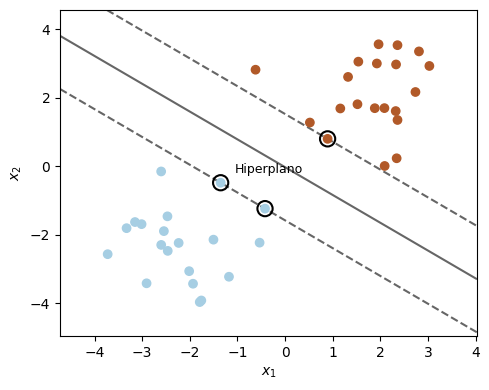

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay

np.random.seed(42)
X = np.r_[np.random.randn(20, 2) - [2, 2], np.random.randn(20, 2) + [2, 2]]
y = [0] * 20 + [1] * 20

clf = svm.SVC(kernel="linear", C=1000)
clf.fit(X, y)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Paired, zorder=10)
DecisionBoundaryDisplay.from_estimator(
    clf, X, plot_method="contour",
    colors="k", levels=[-1, 0, 1],
    alpha=0.6, linestyles=["--", "-", "--"], ax=ax
)
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
           s=120, linewidth=1.5, facecolors="none", edgecolors="k", zorder=11)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.annotate("Hiperplano", xy=(0.5, 0.5), xycoords="axes fraction",
            ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("svm_hiperplano.png", dpi=200, bbox_inches="tight")
plt.show()

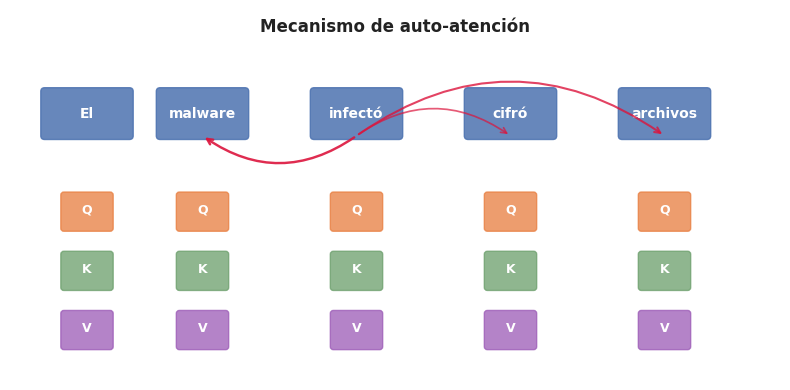

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

# Tokens de ejemplo
tokens = ["El", "malware", "infectó", "cifró", "archivos"]
x_positions = [1, 2.5, 4.5, 6.5, 8.5]
colors = ["#4C72B0"] * 5

for x, tok, col in zip(x_positions, tokens, colors):
    ax.add_patch(mpatches.FancyBboxPatch((x-0.55, 3.3), 1.1, 0.6,
                 boxstyle="round,pad=0.05", color=col, alpha=0.85))
    ax.text(x, 3.6, tok, ha="center", va="center", color="white",
            fontsize=10, fontweight="bold")

# Flechas de atención desde "cifró" hacia "malware" y "archivos"
attention_pairs = [(4.5, 2.5, 0.7), (4.5, 6.5, 0.5), (4.5, 8.5, 0.6)]
for src, tgt, weight in attention_pairs:
    ax.annotate("", xy=(tgt, 3.3), xytext=(src, 3.3),
                arrowprops=dict(arrowstyle="->", color="crimson",
                                lw=weight*2.5, alpha=weight+0.2,
                                connectionstyle="arc3,rad=-0.35"))

# Q, K, V debajo
for x, tok in zip(x_positions, tokens):
    for dy, label, col in zip([2.3, 1.5, 0.7], ["Q", "K", "V"],
                               ["#E87D3E", "#6A9E6A", "#9B59B6"]):
        ax.add_patch(mpatches.FancyBboxPatch((x-0.3, dy-0.25), 0.6, 0.45,
                     boxstyle="round,pad=0.04", color=col, alpha=0.75))
        ax.text(x, dy, label, ha="center", va="center", color="white",
                fontsize=9, fontweight="bold")

ax.text(5, 4.7, "Mecanismo de auto-atención", ha="center",
        fontsize=12, fontweight="bold", color="#222")

plt.tight_layout()
plt.savefig("self_attention.png", dpi=200, bbox_inches="tight")
plt.show()

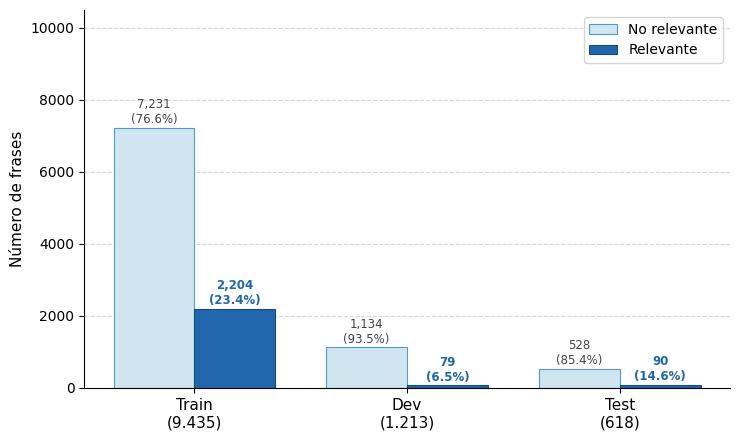

distribucion_dataset.png guardada


In [ ]:


import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

C_REL   = "#2166ac"   # azul oscuro – clase relevante
C_NOREL = "#d1e5f0"   # azul claro  – no relevante
C_DARK  = "#1a1a2e"


splits   = ["Train\n(9.435)", "Dev\n(1.213)", "Test\n(618)"]
relevant = [2204,  79,  90]
total    = [9435, 1213, 618]
no_rel   = [t - r for t, r in zip(total, relevant)]
pct_rel  = [r / t * 100 for r, t in zip(relevant, total)]

x = np.arange(len(splits))
w = 0.38

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars_no = ax.bar(x - w/2, no_rel,   w, label="No relevante",
                 color=C_NOREL, edgecolor="#4d9dc4", linewidth=0.8)
bars_re = ax.bar(x + w/2, relevant, w, label="Relevante",
                 color=C_REL,   edgecolor="#144d7a", linewidth=0.8)

for bar, val, pct in zip(bars_no, no_rel, [100 - p for p in pct_rel]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom",
            fontsize=8.5, color="#444")
for bar, val, pct in zip(bars_re, relevant, pct_rel):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
            f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom",
            fontsize=8.5, color=C_REL, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(splits, fontsize=11)
ax.set_ylabel("Número de frases", fontsize=11)
ax.set_ylim(0, 10500)
ax.legend(fontsize=10, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("distribucion_dataset.png", dpi=200, bbox_inches="tight")
plt.show()
print("distribucion_dataset.png guardada")
